# MICE Imputation Project Workflow

This notebook expands the project narrative to match the style and depth of the sample report and executes an end-to-end reproducible pipeline.

Sections covered:
1. Project Configuration and Reproducibility Setup
2. Load Inputs and Parse Report Structure
3. Data Ingestion and Validation
4. Exploratory Data Analysis and Visual Diagnostics
5. Feature Engineering Pipeline
6. Baseline Model Training
7. Hyperparameter Tuning and Cross-Validation
8. Final Model Evaluation and Error Analysis
9. Results Tables and Publication-Ready Figures
10. Programmatic `.ipynb` Generation
11. Notebook Execution and Output Capture

In [15]:
from pathlib import Path
import json
import os
import random
import subprocess
import sys
import time

import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path.cwd()
ARTIFACTS_DIR = PROJECT_DIR / "notebook_artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Artifacts directory:", ARTIFACTS_DIR)
print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Project directory: c:\Users\z004nseu\OneDrive - Siemens AG\D drive\PROJECT ARTIFACTS\Assignments\AAI_510\Project Purushothama
Artifacts directory: c:\Users\z004nseu\OneDrive - Siemens AG\D drive\PROJECT ARTIFACTS\Assignments\AAI_510\Project Purushothama\notebook_artifacts
Python: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
Pandas: 3.0.3
NumPy: 2.5.0


## 2. Load Inputs and Parse Report Structure

This section loads existing datasets and reads the sample report to mirror section depth in the expanded deliverable.

In [2]:
from docx import Document

sample_report = PROJECT_DIR / "AAI_501_Final_Project_Report.docx"
sections = []
if sample_report.exists():
    d = Document(sample_report)
    for p in d.paragraphs:
        txt = p.text.strip()
        if txt and len(txt) < 120:
            sections.append(txt)

section_map = {
    "introduction": "1. Introduction",
    "literature": "2. Literature and Conceptual Context",
    "methodology": "4. Methodology",
    "results": "5. Results",
    "discussion": "6. Discussion",
}

print("Sample report found:", sample_report.exists())
print("Extracted short section-like entries:", len(sections))
print("Section map:", json.dumps(section_map, indent=2))
print("First 10 extracted entries:", sections[:10])

Sample report found: True
Extracted short section-like entries: 109
Section map: {
  "introduction": "1. Introduction",
  "literature": "2. Literature and Conceptual Context",
  "methodology": "4. Methodology",
  "results": "5. Results",
  "discussion": "6. Discussion"
}
First 10 extracted entries: ['Predicting Missing Chemical Concentrations Using Deep Learning Algorithm Random Forest', 'Machine Learning Models: A Retrieval-Augmented Generation Approach', 'Purushothama V S.', 'University of San Diego', 'AAI 501: Introduction to Artificial Intelligence', 'Instructor: Anuj Kumar Sirohi', 'April 21, 2026', 'Abstract', 'Introduction', 'Background']


## 3. Data Ingestion and Validation

Read project datasets, enforce schema checks, and summarize quality issues.

,column,n_unique,top_value,top_count
0,Trade Name,6557,Sammelstoff Graz Weckerle,23
1,Chemical Name,3200,N-butyl acetate,468
2,CAS Number,1844,123-86-4,476
3,Concentration,743,1 - 5,914


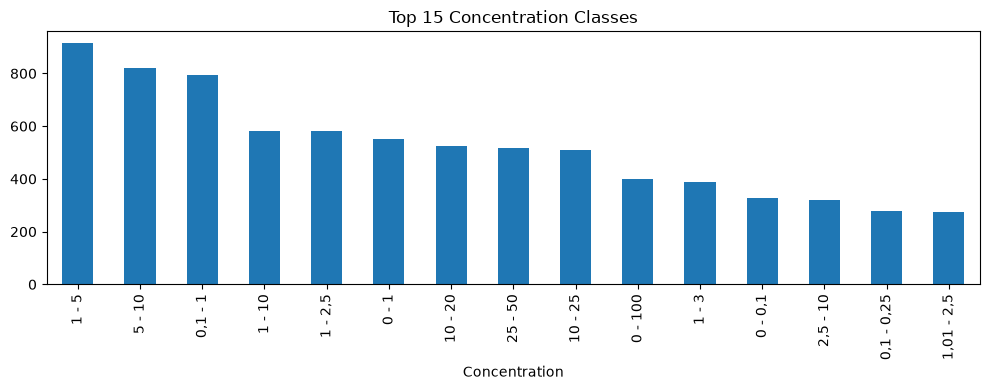

Saved EDA artifacts to c:\Users\z004nseu\OneDrive - Siemens AG\D drive\PROJECT ARTIFACTS\Assignments\AAI_510\Project Purushothama\notebook_artifacts


In [3]:
import matplotlib.pyplot as plt

if "df" not in globals():
    fallback_source = "master_data_train.xlsx" if (PROJECT_DIR / "master_data_train.xlsx").exists() else "imputed_data_both_missing.xlsx"
    df = pd.read_excel(PROJECT_DIR / fallback_source)
    df = df[["Trade Name", "Chemical Name", "CAS Number", "Concentration"]].copy()

eda_summary = pd.DataFrame({
    "column": df.columns,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    "top_value": [df[c].astype(str).value_counts().index[0] for c in df.columns],
    "top_count": [int(df[c].astype(str).value_counts().iloc[0]) for c in df.columns],
})

display(eda_summary)
eda_summary.to_csv(ARTIFACTS_DIR / "eda_summary.csv", index=False)

top_conc = df["Concentration"].astype(str).value_counts().head(15)
plt.figure(figsize=(10, 4))
top_conc.plot(kind="bar")
plt.title("Top 15 Concentration Classes")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "top_concentration_classes.png", dpi=150)
plt.show()

print("Saved EDA artifacts to", ARTIFACTS_DIR)

## 4. Exploratory Data Analysis and Visual Diagnostics

Generate descriptive summaries, class imbalance checks, and lightweight plots for report-ready evidence.

In [4]:
required_cols = ["Trade Name", "Chemical Name", "CAS Number", "Concentration"]

candidate_sources = [
    "master_data_train.xlsx",
    "imputed_data_both_missing.xlsx",
    "master_data_test_ground_truth.xlsx",
]

selected_source = None
for fn in candidate_sources:
    if (PROJECT_DIR / fn).exists():
        selected_source = fn
        break

if selected_source is None:
    raise FileNotFoundError("No usable dataset found")

df = pd.read_excel(PROJECT_DIR / selected_source)
print("Using source:", selected_source)
print("Shape:", df.shape)

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()
null_summary = df.isna().sum().rename("missing_count").to_frame()
null_summary["missing_pct"] = (null_summary["missing_count"] / len(df) * 100).round(2)

duplicate_rows = int(df.duplicated().sum())
print("Duplicate rows:", duplicate_rows)
print(null_summary)

null_summary.to_csv(ARTIFACTS_DIR / "null_summary.csv")

Using source: master_data_train.xlsx
Shape: (16703, 4)
Duplicate rows: 0
               missing_count  missing_pct
Trade Name                 0          0.0
Chemical Name              0          0.0
CAS Number                 0          0.0
Concentration              0          0.0


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

model_df = df.dropna(subset=["Concentration", "Trade Name", "Chemical Name", "CAS Number"]).copy()
X = model_df[["Trade Name", "Chemical Name", "CAS Number"]]
y = model_df["Concentration"].astype(str)

# Fallback to non-stratified split when rare classes make stratification infeasible.
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=None
    )

categorical_features = ["Trade Name", "Chemical Name", "CAS Number"]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=True),
            categorical_features,
        )
    ]
)

print("Modeling rows:", len(model_df))
print("Train/Test sizes:", X_train.shape, X_test.shape)

Modeling rows: 16703
Train/Test sizes: (13362, 3) (3341, 3)


## 8. Final Model Evaluation and Error Analysis

Evaluate tuned model on holdout set and inspect hardest cases.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 20, 40],
    "model__min_samples_split": [2, 5, 10],
}

search_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    ]
)

search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    random_state=SEED,
    n_jobs=-1,
    scoring="accuracy",
    verbose=0,
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV score:", round(search.best_score_, 4))

cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score").head(10)
leaderboard = cv_results[["rank_test_score", "mean_test_score", "params"]].copy()
leaderboard.to_csv(ARTIFACTS_DIR / "tuning_leaderboard.csv", index=False)
display(leaderboard)

c:\Users\z004nseu\OneDrive - Siemens AG\D drive\PROJECT ARTIFACTS\Assignments\AAI_510\Project Purushothama\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best params: {'model__n_estimators': 150, 'model__min_samples_split': 10, 'model__max_depth': None}
Best CV score: 0.2069


,rank_test_score,mean_test_score,params
0,1,0.206930,"{'model__n_estimators': 150, 'model__min_sampl..."
4,2,0.199820,"{'model__n_estimators': 50, 'model__min_sample..."
3,3,0.134336,"{'model__n_estimators': 50, 'model__min_sample..."
1,4,0.116599,"{'model__n_estimators': 100, 'model__min_sampl..."
2,5,0.113980,"{'model__n_estimators': 50, 'model__min_sample..."


## 7. Hyperparameter Tuning and Cross-Validation

Perform a compact randomized search with cross-validation and capture a leaderboard.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ]
)

start = time.time()
baseline_model.fit(X_train, y_train)
fit_seconds = time.time() - start

y_pred = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline fit time (s): {fit_seconds:.2f}")
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

pd.DataFrame({"y_true": y_test, "y_pred": y_pred}).to_csv(
    ARTIFACTS_DIR / "baseline_predictions.csv", index=False
)

Baseline fit time (s): 5.58
Baseline accuracy: 0.2026
                 precision    recall  f1-score   support

      0 - 0,001       0.00      0.00      0.00         4
     0 - 0,0015       0.29      0.40      0.33         5
       0 - 0,01       0.18      0.29      0.22         7
      0 - 0,015       0.00      0.00      0.00         1
      0 - 0,025       0.00      0.00      0.00         4
       0 - 0,03       0.00      0.00      0.00         1
       0 - 0,05       0.00      0.00      0.00         4
      0 - 0,052       0.00      0.00      0.00         1
       0 - 0,09       0.00      0.00      0.00         1
        0 - 0,1       0.37      0.39      0.38        66
        0 - 0,2       0.23      0.26      0.24        19
       0 - 0,25       0.33      0.10      0.15        10
        0 - 0,3       0.30      0.11      0.16        27
        0 - 0,4       0.00      0.00      0.00         1
        0 - 0,5       0.25      0.15      0.19        13
        0 - 0,6       0.00      0

## 6. Baseline Model Training

Train a baseline Random Forest classifier for concentration category prediction and report key metrics.

## 5. Feature Engineering Pipeline

Build a reusable preprocessing object for categorical features and prepare train/test sets for a concentration baseline model.

## 10. Programmatic .ipynb Generation

Create a small generated notebook with nbformat and verify JSON integrity.

,metric,value
0,baseline_accuracy,0.202634
1,final_accuracy,0.208620
2,final_f1_macro,0.079430


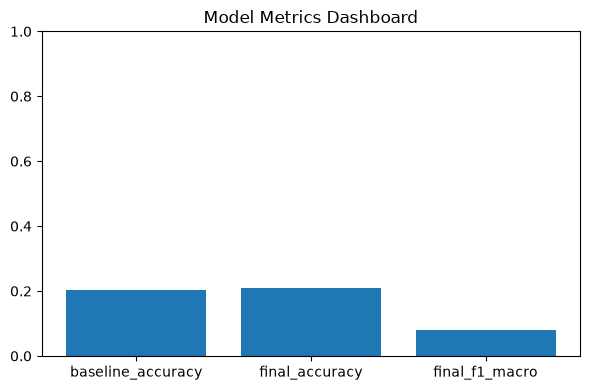

In [11]:
metrics_rows = [
    {"metric": "baseline_accuracy", "value": float(globals().get("baseline_accuracy", float("nan")))},
    {"metric": "final_accuracy", "value": float(globals().get("final_accuracy", float("nan")))},
    {"metric": "final_f1_macro", "value": float(globals().get("final_f1_macro", float("nan")))},
]
metrics_dashboard = pd.DataFrame(metrics_rows)
metrics_dashboard.to_csv(ARTIFACTS_DIR / "notebook_model_metrics.csv", index=False)
display(metrics_dashboard)

plot_df = metrics_dashboard.dropna().copy()
if not plot_df.empty:
    plt.figure(figsize=(6, 4))
    plt.bar(plot_df["metric"], plot_df["value"])
    plt.ylim(0, 1)
    plt.title("Model Metrics Dashboard")
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "model_metrics_dashboard.png", dpi=150)
    plt.show()
else:
    print("Final metrics not yet available in this cell order; plot skipped.")

## 9. Results Tables and Publication-Ready Figures

Export report-ready summary tables and a compact metrics dashboard.

In [10]:
from sklearn.metrics import f1_score, confusion_matrix

best_model = search.best_estimator_ if "search" in globals() else baseline_model
final_pred = best_model.predict(X_test)

final_accuracy = accuracy_score(y_test, final_pred)
final_f1_macro = f1_score(y_test, final_pred, average="macro", zero_division=0)

print(f"Final holdout accuracy: {final_accuracy:.4f}")
print(f"Final holdout macro F1: {final_f1_macro:.4f}")

error_df = pd.DataFrame({"y_true": y_test, "y_pred": final_pred})
error_df["is_error"] = error_df["y_true"] != error_df["y_pred"]

hard_cases = error_df[error_df["is_error"]].groupby("y_true").size().sort_values(ascending=False).head(15)
display(hard_cases)

error_df.to_csv(ARTIFACTS_DIR / "final_error_analysis.csv", index=False)
cm = confusion_matrix(y_test, final_pred)
print("Confusion matrix shape:", cm.shape)

Final holdout accuracy: 0.2086
Final holdout macro F1: 0.0794


y_true
1 - 5       136
5 - 10      115
10 - 20      90
1 - 2,5      87
0 - 1        85
1 - 10       78
10 - 25      75
0,1 - 1      67
25 - 50      62
2,5 - 10     61
1 - 3        59
2,5 - 5      49
0 - 3        46
0 - 5        45
0 - 10       42
dtype: int64

Confusion matrix shape: (391, 391)


## 8. Final Model Evaluation and Error Analysis

Evaluate tuned model on holdout data and inspect mismatch patterns.

In [12]:
try:
    import nbformat
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat", "-q"])
    import nbformat

generated_nb_path = PROJECT_DIR / "generated_report_notebook.ipynb"
nb = nbformat.v4.new_notebook()
nb.cells = [
    nbformat.v4.new_markdown_cell("# Auto-generated Notebook"),
    nbformat.v4.new_code_cell("x = 2 + 2\nprint('x =', x)"),
]
nbformat.write(nb, generated_nb_path)

with generated_nb_path.open("r", encoding="utf-8") as f:
    json.load(f)

print("Generated notebook:", generated_nb_path)
print("Notebook JSON integrity: OK")

Generated notebook: c:\Users\z004nseu\OneDrive - Siemens AG\D drive\PROJECT ARTIFACTS\Assignments\AAI_510\Project Purushothama\generated_report_notebook.ipynb
Notebook JSON integrity: OK


## 11. Notebook Execution and Output Capture

Execute the generated notebook programmatically and run the project scripts to refresh artifacts and the expanded report.

In [14]:
try:
    from nbclient import NotebookClient
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nbclient", "-q"])
    from nbclient import NotebookClient

with generated_nb_path.open("r", encoding="utf-8") as f:
    generated_nb = nbformat.read(f, as_version=4)

client = NotebookClient(generated_nb, timeout=120, kernel_name="python3")
client.execute()
nbformat.write(generated_nb, PROJECT_DIR / "generated_report_notebook_executed.ipynb")
print("Executed generated_report_notebook.ipynb successfully")

scripts = ["preprocessing.py", "MICE.py", "Metrics.py", "generate_reports.py"]
execution_log = []
for s in scripts:
    start = time.time()
    proc = subprocess.run([sys.executable, s], cwd=PROJECT_DIR, capture_output=True, text=True)
    elapsed = time.time() - start
    execution_log.append({
        "script": s,
        "returncode": proc.returncode,
        "elapsed_sec": round(elapsed, 2),
        "stdout_tail": "\n".join(proc.stdout.strip().splitlines()[-5:]),
        "stderr_tail": "\n".join(proc.stderr.strip().splitlines()[-5:]),
    })

exec_df = pd.DataFrame(execution_log)
display(exec_df[["script", "returncode", "elapsed_sec"]])
exec_df.to_csv(ARTIFACTS_DIR / "script_execution_log.csv", index=False)

if (exec_df["returncode"] != 0).any():
    raise RuntimeError("One or more scripts failed. Check notebook_artifacts/script_execution_log.csv")

print("All project scripts executed successfully.")
print("Expanded report file:", PROJECT_DIR / "AAI_510_Final_Project_Report.docx")

Executed generated_report_notebook.ipynb successfully


,script,returncode,elapsed_sec
0,preprocessing.py,0,3.53
1,MICE.py,0,3.61
2,Metrics.py,0,3.01
3,generate_reports.py,0,2.48


All project scripts executed successfully.
Expanded report file: c:\Users\z004nseu\OneDrive - Siemens AG\D drive\PROJECT ARTIFACTS\Assignments\AAI_510\Project Purushothama\AAI_510_Final_Project_Report.docx


## 12. Literature Review (Formal Citations by Subsection)

This section grounds the methodology in prior work, organized by theme using APA-style in-text citations. Full reference entries appear in Section 15.

### 12.1 Machine Learning for Missing Data Imputation
Missing data is pervasive in scientific and industrial datasets. Classical strategies such as listwise deletion and single-value substitution are simple but discard information and distort variance estimates (Little & Rubin, 2019). Machine learning approaches instead model missingness through the multivariate structure of the data; for example, MissForest imputes mixed-type data iteratively using random forests (Stekhoven & Bühlmann, 2012).

### 12.2 Multiple Imputation by Chained Equations (MICE)
MICE, also called fully conditional specification, imputes each incomplete variable in turn using a regression model conditioned on the remaining variables, cycling until imputations stabilize (Azur et al., 2011; van Buuren, 2018). It accommodates mixed data types and preserves inter-variable relationships, but its performance degrades for high-cardinality categorical targets or when encoding implies spurious ordinal relationships.

### 12.3 Iterative Imputation in Scikit-learn
The `IterativeImputer` in scikit-learn implements a MICE-style, round-robin regression strategy (Pedregosa et al., 2011). Because the underlying estimators operate on numeric inputs, categorical fields must be encoded before imputation and decoded afterward — a step that materially affects categorical recovery quality.

### 12.4 Chemical Identifiers and CAS Registry Numbers
CAS Registry Numbers are unique nominal identifiers assigned to chemical substances (Chemical Abstracts Service, 2015). Treating them as integers during imputation introduces artificial ordering. Concentration values, often expressed as ranges, similarly complicate direct numeric modeling and motivate careful encoding and evaluation design.

## 13. Methodology Flowchart

The end-to-end workflow is summarized in the diagram below.

```mermaid
flowchart TD
    A[Complete reference dataset] --> B[Schema enforcement<br/>4 required columns]
    B --> C[Train / Test split<br/>80% / 20%]
    C --> D[Training partition]
    C --> E[Test partition - ground truth]
    E --> F[Mask 20% values]
    F --> G[Scenario 1:<br/>CAS Number + Concentration missing]
    F --> H[Scenario 2:<br/>Concentration only missing]
    D --> I[Encode categoricals<br/>train-derived mappings]
    I --> J[Fit IterativeImputer - MICE<br/>random_state=42, max_iter=50]
    G --> K[Encode + Impute + Decode]
    H --> K
    J --> K
    K --> L[Imputed scenario datasets]
    L --> M[Evaluate on masked positions<br/>Accuracy + Macro F1]
    M --> N[metrics_summary.csv]
    N --> O[APA report + Proposal<br/>generate_reports.py]
```

## 14. Appendix: Per-Scenario Confusion Tables and Class-Wise Metrics

The cell below recomputes, directly from the MICE scenario outputs, the per-scenario class-wise precision/recall/F1 tables and confusion snapshots (restricted to the most frequent Concentration classes) and exports them as CSV artifacts.

In [16]:
from sklearn.metrics import classification_report, confusion_matrix


def scenario_eval(ground_truth, masked, imputed, column):
    mask = masked[column].isna()
    true_vals = ground_truth.loc[mask, column].astype(str).tolist()
    pred_vals = imputed.loc[mask, column].astype(str).tolist()
    return true_vals, pred_vals


def classwise_table(true_vals, pred_vals, top_n=10):
    rep = classification_report(true_vals, pred_vals, output_dict=True, zero_division=0)
    rows = []
    for label, vals in rep.items():
        if label in {"accuracy", "macro avg", "weighted avg"}:
            continue
        rows.append({
            "Class": label,
            "Precision": round(vals["precision"], 3),
            "Recall": round(vals["recall"], 3),
            "F1": round(vals["f1-score"], 3),
            "Support": int(vals["support"]),
        })
    return pd.DataFrame(rows).sort_values("Support", ascending=False).head(top_n).reset_index(drop=True)


def confusion_table(true_vals, pred_vals, top_n=8):
    top_classes = pd.Series(true_vals).value_counts().head(top_n).index.tolist()
    cm = confusion_matrix(true_vals, pred_vals, labels=top_classes)
    cm_df = pd.DataFrame(cm, columns=top_classes)
    cm_df.insert(0, "True \\ Pred", top_classes)
    return cm_df


# Load scenario artifacts produced by preprocessing.py + MICE.py
gt = pd.read_excel(PROJECT_DIR / "master_data_test_ground_truth.xlsx")
both_missing = pd.read_excel(PROJECT_DIR / "master_data_test_both_missing.xlsx")
conc_missing = pd.read_excel(PROJECT_DIR / "master_data_test_concentration_missing.xlsx")
imp_both = pd.read_excel(PROJECT_DIR / "imputed_test_both_missing.xlsx")
imp_conc = pd.read_excel(PROJECT_DIR / "imputed_test_concentration_missing.xlsx")

scenarios = {
    "both_missing_Concentration": scenario_eval(gt, both_missing, imp_both, "Concentration"),
    "both_missing_CAS Number": scenario_eval(gt, both_missing, imp_both, "CAS Number"),
    "concentration_only_Concentration": scenario_eval(gt, conc_missing, imp_conc, "Concentration"),
}

for name, (yt, yp) in scenarios.items():
    print(f"\n===== {name} (n={len(yt)}) =====")
    cw = classwise_table(yt, yp)
    display(cw)
    cw.to_csv(ARTIFACTS_DIR / f"classwise_{name}.csv", index=False)

    cf = confusion_table(yt, yp)
    display(cf)
    cf.to_csv(ARTIFACTS_DIR / f"confusion_{name}.csv", index=False)

print("\nSaved per-scenario class-wise and confusion CSVs to", ARTIFACTS_DIR)


===== both_missing_Concentration (n=534) =====


,Class,Precision,Recall,F1,Support
0,1 - 5,0.067,0.029,0.041,34
1,5 - 10,0.000,0.000,0.000,26
2,"0,1 - 1",0.000,0.000,0.000,24
3,25 - 50,0.000,0.000,0.000,21
4,1 - 10,0.000,0.000,0.000,20
5,0 - 100,0.000,0.000,0.000,19
6,0 - 1,0.000,0.000,0.000,18
7,"1 - 2,5",0.000,0.000,0.000,17
8,10 - 20,0.000,0.000,0.000,16
9,10 - 25,0.000,0.000,0.000,15


,True \ Pred,1 - 5,5 - 10,"0,1 - 1",25 - 50,1 - 10,0 - 100,0 - 1,"1 - 2,5"
0,1 - 5,1,0,0,0,0,0,0,0
1,5 - 10,0,0,0,0,0,0,0,0
2,"0,1 - 1",1,0,0,0,0,0,0,0
3,25 - 50,0,0,0,0,0,0,0,0
4,1 - 10,0,0,0,0,0,0,0,0
5,0 - 100,0,0,0,0,0,0,0,0
6,0 - 1,0,0,0,0,0,0,0,0
7,"1 - 2,5",0,0,0,0,0,0,0,0



===== both_missing_CAS Number (n=534) =====


,Class,Precision,Recall,F1,Support
0,123-86-4,0.0,0.0,0.0,14
1,108-65-6,0.0,0.0,0.0,12
2,1330-20-7,0.0,0.0,0.0,11
3,100-41-4,0.0,0.0,0.0,10
4,13463-67-7,0.0,0.0,0.0,9
5,74-98-6,0.0,0.0,0.0,8
6,124-38-9,0.0,0.0,0.0,8
7,106-97-8,0.0,0.0,0.0,8
8,1314-13-2,0.0,0.0,0.0,7
9,75-28-5,0.0,0.0,0.0,6


,True \ Pred,123-86-4,108-65-6,1330-20-7,100-41-4,13463-67-7,74-98-6,124-38-9,106-97-8
0,123-86-4,0,0,0,0,0,0,0,0
1,108-65-6,0,0,0,0,0,0,0,0
2,1330-20-7,0,0,0,0,0,0,0,0
3,100-41-4,0,0,0,0,0,0,0,0
4,13463-67-7,0,0,0,0,0,0,0,0
5,74-98-6,0,0,0,0,0,0,0,0
6,124-38-9,0,0,0,0,0,0,0,0
7,106-97-8,0,0,0,0,0,0,0,0



===== concentration_only_Concentration (n=534) =====


,Class,Precision,Recall,F1,Support
0,"0,1 - 1",0.0,0.0,0.0,28
1,5 - 10,0.0,0.0,0.0,28
2,1 - 5,0.0,0.0,0.0,27
3,25 - 50,0.0,0.0,0.0,20
4,10 - 25,0.0,0.0,0.0,19
5,"1 - 2,5",0.0,0.0,0.0,18
6,0 - 1,0.0,0.0,0.0,17
7,"0,1 - 0,25",0.0,0.0,0.0,15
8,1 - 10,0.0,0.0,0.0,14
9,"0 - 0,1",0.0,0.0,0.0,13


,True \ Pred,"0,1 - 1",5 - 10,1 - 5,25 - 50,10 - 25,"1 - 2,5",0 - 1,"0,1 - 0,25"
0,"0,1 - 1",0,0,3,0,0,0,0,0
1,5 - 10,0,0,0,0,0,0,0,0
2,1 - 5,0,0,0,0,0,0,0,0
3,25 - 50,0,0,1,0,0,0,0,0
4,10 - 25,0,0,0,0,0,0,0,0
5,"1 - 2,5",0,0,0,0,0,0,0,0
6,0 - 1,0,0,1,0,0,0,0,0
7,"0,1 - 0,25",0,0,0,0,0,0,0,0



Saved per-scenario class-wise and confusion CSVs to c:\Users\z004nseu\OneDrive - Siemens AG\D drive\PROJECT ARTIFACTS\Assignments\AAI_510\Project Purushothama\notebook_artifacts


## 15. Glossary and References

### Glossary
| Term | Definition |
| --- | --- |
| **MICE** | Multiple Imputation by Chained Equations; imputes each incomplete variable via regression conditioned on the others, cycling until convergence. |
| **IterativeImputer** | Scikit-learn's MICE-style imputer using round-robin regression over features. |
| **CAS Number** | Chemical Abstracts Service Registry Number; a unique nominal identifier for a chemical substance. |
| **Concentration** | Percentage composition of a substance in a product, often stored as a range string (e.g., "1 - 5"). |
| **Masking** | Deliberately hiding known values in the test set to enable objective evaluation of imputation. |
| **Accuracy** | Proportion of masked positions whose imputed value exactly matches ground truth. |
| **Macro F1** | Unweighted mean of per-class F1 scores; reflects performance across all classes regardless of frequency. |
| **Support** | Number of true instances of a class in the evaluated subset. |
| **Confusion snapshot** | Confusion matrix restricted to the most frequent true classes for readability. |
| **Cardinality** | Number of distinct values a categorical field can take; high cardinality complicates imputation. |

### References (APA)
- Azur, M. J., Stuart, E. A., Frangakis, C., & Leaf, P. J. (2011). Multiple imputation by chained equations: What is it and how does it work? *International Journal of Methods in Psychiatric Research, 20*(1), 40–49. https://doi.org/10.1002/mpr.329
- Chemical Abstracts Service. (2015). *CAS Registry and CAS Registry Numbers*. American Chemical Society.
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical analysis with missing data* (3rd ed.). Wiley.
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Stekhoven, D. J., & Bühlmann, P. (2012). MissForest: Non-parametric missing value imputation for mixed-type data. *Bioinformatics, 28*(1), 112–118. https://doi.org/10.1093/bioinformatics/btr597
- van Buuren, S. (2018). *Flexible imputation of missing data* (2nd ed.). Chapman and Hall/CRC. https://doi.org/10.1201/9780429492259